In [ ]:
import gensim.downloader as api
from gensim.models import FastText
from gensim.utils import simple_preprocess
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import fasttext
import fasttext.util
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("food.csv")

names = df["nome"].tolist()
vectors = df.drop(columns=["nome"]).values
vectors_centered = vectors - vectors.mean(axis=1, keepdims=True)

sim_matrix = cosine_similarity(vectors_centered)

sns.heatmap(sim_matrix, xticklabels=names, yticklabels=names,
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Afinidade gastronômica")
plt.show()

In [ ]:
#fasttext.util.download_model('pt', if_exists='ignore')
ft = fasttext.load_model('cc.pt.300.bin')

In [ ]:
dictionary_words = pd.read_csv("../session_4_dba/data/dict.csv", sep=";")["answer"]

In [ ]:
for word in dictionary_words:
    neighbors = ft.get_nearest_neighbors(word, k=5)
    print(f"\n{word}:")
    for score, neighbor in neighbors:
        print(f"  {neighbor} ({score:.3f})")

In [ ]:
data = pd.read_csv("../session_4_dba/data/fakeWhatsApp.BR_2018_content_only.csv")

In [ ]:
corpus = [simple_preprocess(doc) for doc in data["text"]]

model = FastText(sentences=corpus, vector_size=300, window=5, min_count=5, epochs=20)

In [ ]:
for word in dictionary_words:
    neighbors = model.wv.most_similar(word, topn=5)
    print(f"\n{word}:")
    for neighbor, score in neighbors:
        print(f"  {neighbor} ({score:.3f})")

In [ ]:
word = "lula"

print("PRETRAINED:")
for score, neighbor in ft.get_nearest_neighbors(word, k=5):
    print(f"  {neighbor} ({score:.3f})")

print("\nTRAINED ON WHATSAPP:")
for neighbor, score in model.wv.most_similar(word, topn=5):
    print(f"  {neighbor} ({score:.3f})")

In [ ]:
# Pretrained
vectors = np.array([ft.get_word_vector(w) for w in dictionary_words])
sim_matrix = cosine_similarity(vectors)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix, xticklabels=dictionary_words, yticklabels=dictionary_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pretrained model")
plt.show()

In [ ]:
# Get vectors
vectors = np.array([ft.get_word_vector(w) for w in dictionary_words])

centroid = vectors.mean(axis=0)
sim_to_centroid = cosine_similarity(vectors, centroid.reshape(1, -1)).flatten()

ranking = pd.DataFrame({
    "word": dictionary_words,
    "sim_to_centroid": sim_to_centroid
}).sort_values("sim_to_centroid", ascending=False)

print(ranking)

# Keep top N most central words
top_words = ranking.head(20)["word"].tolist()

In [ ]:
# Pretrained
vectors = np.array([ft.get_word_vector(w) for w in top_words])
sim_matrix = cosine_similarity(vectors)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix, xticklabels=top_words, yticklabels=top_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pretrained model")
plt.show()

In [ ]:
vectors_trained = np.array([model.wv[w] for w in top_words])
sim_matrix_trained = cosine_similarity(vectors_trained)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix_trained, xticklabels=top_words, yticklabels=top_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Trained on WhatsApp")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(sim_matrix, xticklabels=top_words, yticklabels=top_words,
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Pretrained model")

sns.heatmap(sim_matrix_trained, xticklabels=top_words, yticklabels=top_words,
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Trained on WhatsApp")

plt.tight_layout()
plt.show()

In [ ]:
# Prune words below threshold
pruning_threshold = ranking["sim_to_centroid"].median()
refined = ranking[ranking["sim_to_centroid"] >= pruning_threshold]
refined_words = refined["word"].tolist()
print(f"Kept {len(refined_words)} of {len(dictionary_words)} words after pruning")

# Find nearest neighbours for remaining words
expansion_threshold = 0.7
new_words = []

for word in refined_words:
    neighbors = ft.get_nearest_neighbors(word, k=3)
    for score, neighbor in neighbors:
        if (score >= expansion_threshold and 
            neighbor not in refined_words and 
            neighbor not in new_words):
            new_words.append({"word": neighbor, "source": word, "score": score})

expansion = pd.DataFrame(new_words).sort_values("score", ascending=False)
print(f"\nNew candidate words: {len(expansion)}")
print(expansion)

expanded_dictionary = refined_words + expansion["word"].tolist()
print(f"\nFinal dictionary size: {len(expanded_dictionary)}")

In [ ]:
new_words_trained = []

for word in refined_words:
    try:
        neighbors = model.wv.most_similar(word, topn=3)
        for neighbor, score in neighbors:
            if (score >= expansion_threshold and
                neighbor not in refined_words and
                neighbor not in new_words_trained):
                new_words_trained.append({"word": neighbor, "source": word, "score": score})
    except KeyError:
        print(f"Not in trained vocab: {word}")

expansion_trained = pd.DataFrame(new_words_trained).sort_values("score", ascending=False)
print(f"New candidate words: {len(expansion_trained)}")
print(expansion_trained)

In [ ]:
# Words found by each model
pretrained_words = set(expansion["word"].tolist())
trained_words = set(expansion_trained["word"].tolist())

# Overlap
overlap = pretrained_words & trained_words
only_pretrained = pretrained_words - trained_words
only_trained = trained_words - pretrained_words

print(f"Found by pretrained only: {len(only_pretrained)}")
print(f"Found by trained only: {len(only_trained)}")
print(f"Found by both: {len(overlap)}")
print(f"Overlap words: {overlap}")

In [ ]:
# print("PRETRAINED:")
# results = ft.get_analogies("político", "homem", "mulher")
# for score, word in results:
#     print(f"  {word} ({score:.3f})")

# print("\nTRAINED ON WHATSAPP:")
# results_trained = model.wv.most_similar(positive=["político", "mulher"], negative=["homem"])
# for word, score in results_trained:
#     print(f"  {word} ({score:.3f})")

c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


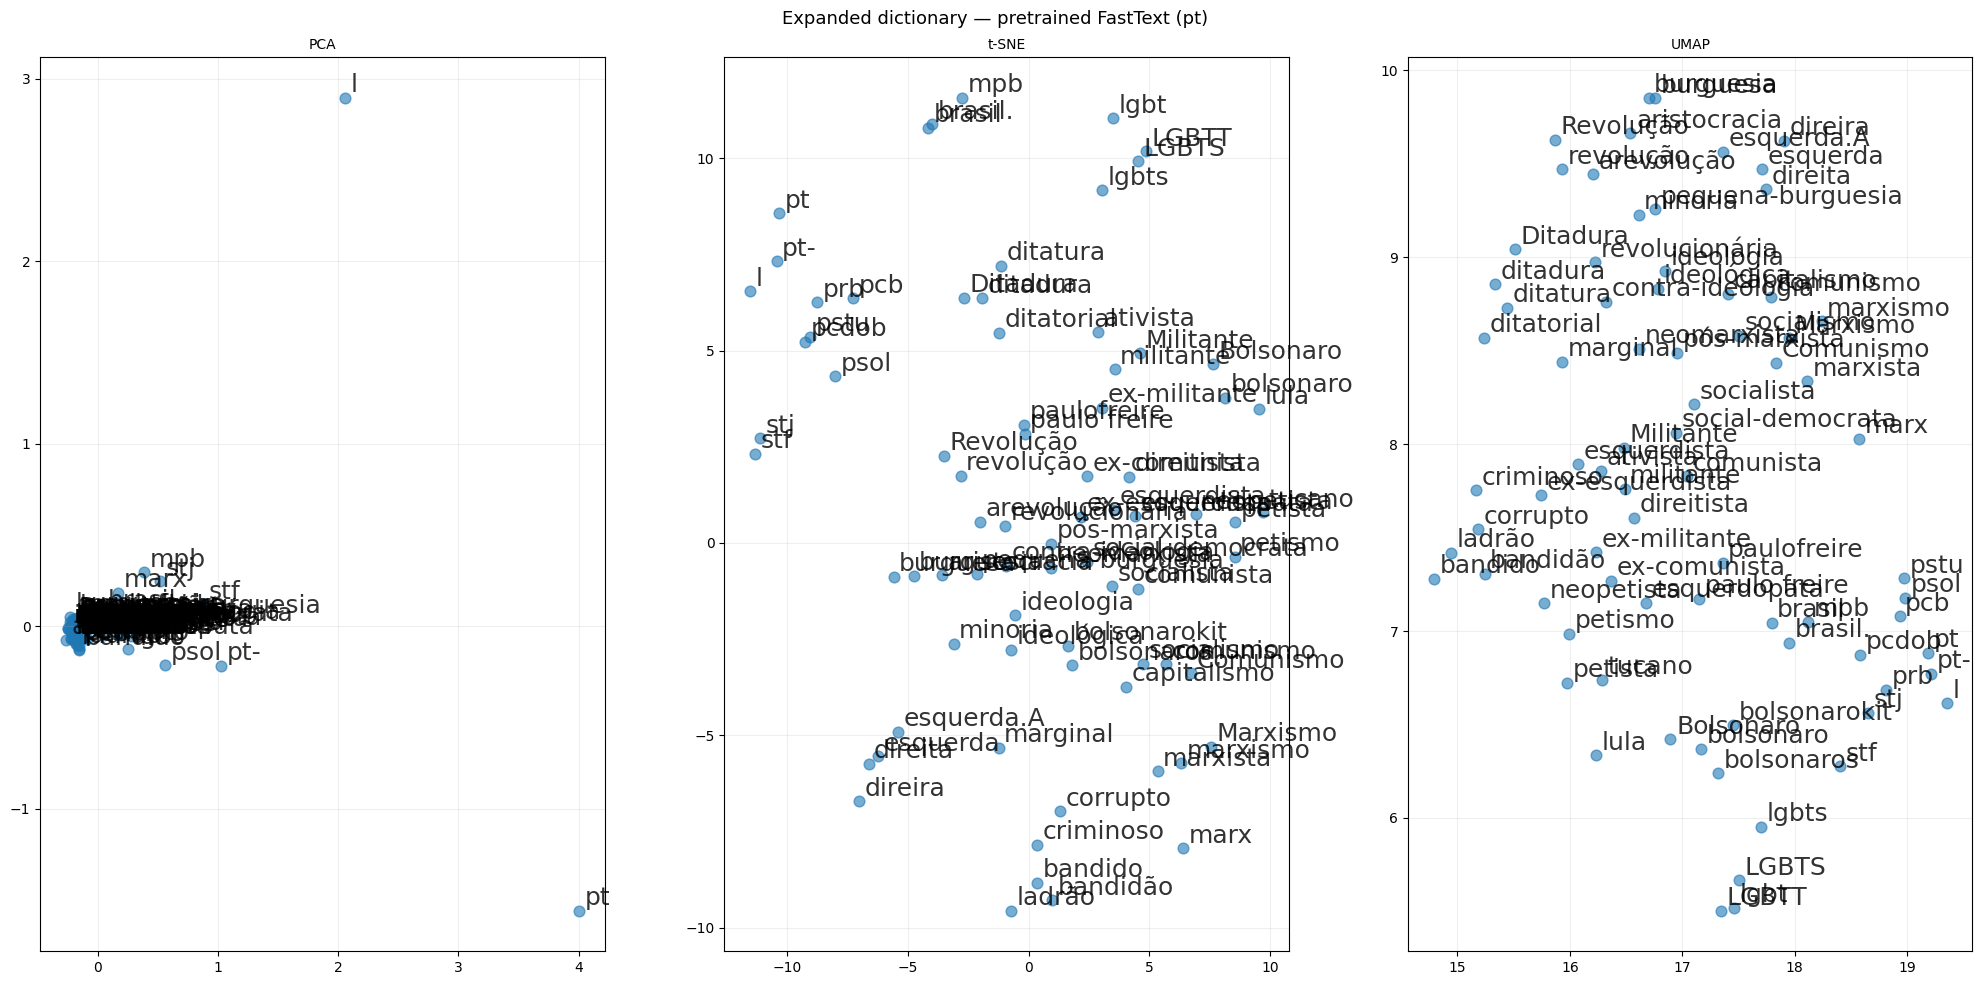

In [ ]:
# Word-level dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

vecs = np.array([ft.get_word_vector(w) for w in expanded_dictionary])

reducers = {
    "PCA":   PCA(n_components=2),
    "t-SNE": TSNE(n_components=2, perplexity=15, random_state=42),
    "UMAP":  UMAP(n_components=2, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle("Expanded dictionary — pretrained FastText (pt)", fontsize=13)

for ax, (method_name, reducer) in zip(axes, reducers.items()):
    coords = reducer.fit_transform(vecs)
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=60)
    for i, word in enumerate(expanded_dictionary):
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=18, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")
    ax.set_title(method_name, fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("word_dimreduction.png", dpi=150, bbox_inches="tight")
plt.show()

c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


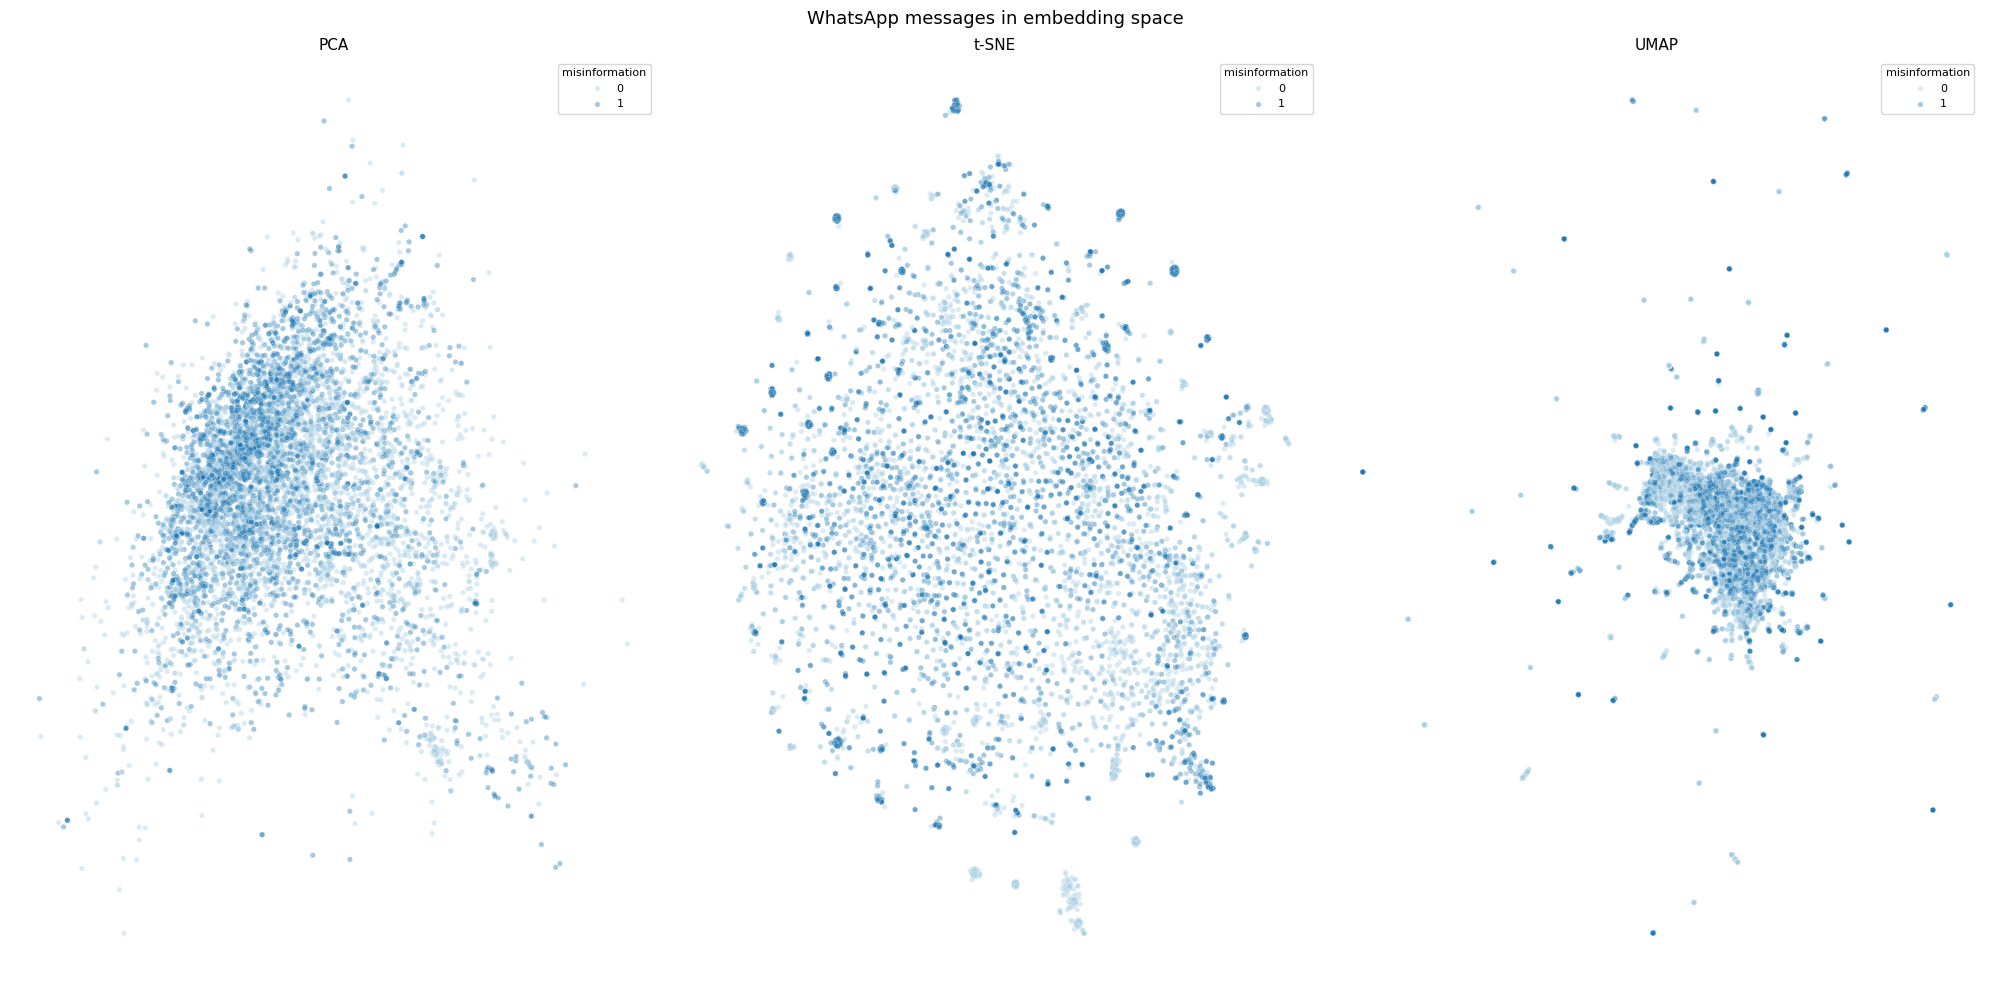

In [ ]:
# Extract doc embeddings

def doc_vector(text, model_wv):
    tokens = simple_preprocess(str(text))
    vecs = [model_wv[w] for w in tokens if w in model_wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model_wv.vector_size)

data["vector"] = data["text"].apply(lambda t: doc_vector(t, model.wv))

mask = data["vector"].apply(lambda v: v.sum() != 0)
data_clean = data[mask].reset_index(drop=True)

doc_matrix = np.vstack(data_clean["vector"].values)

# Reduce to 2D
coords_umap = UMAP(n_components=2, random_state=42).fit_transform(doc_matrix)
coords_pca  = PCA(n_components=2).fit_transform(doc_matrix)
coords_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(doc_matrix)

data_clean["umap_x"], data_clean["umap_y"] = coords_umap[:, 0], coords_umap[:, 1]
data_clean["pca_x"],  data_clean["pca_y"]  = coords_pca[:, 0],  coords_pca[:, 1]
data_clean["tsne_x"], data_clean["tsne_y"] = coords_tsne[:, 0], coords_tsne[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle("WhatsApp messages in embedding space", fontsize=13)

for ax, (method, x_col, y_col) in zip(axes, [
    ("PCA",   "pca_x",   "pca_y"),
    ("t-SNE", "tsne_x",  "tsne_y"),
    ("UMAP",  "umap_x",  "umap_y"),
]):
    sns.scatterplot(
        data=data_clean, x=x_col, y=y_col,
        hue="misinformation",      
        alpha=0.4, s=15,
        palette="Paired", ax=ax
    )
    ax.set_title(method, fontsize=11)
    ax.grid(alpha=0.2)
    ax.legend(title="misinformation", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.savefig("doc_embeddings_misinfo.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Interactive plots with hover (PCA / t-SNE / UMAP)
import plotly.express as px

data_clean["preview"] = data_clean["text"].str.slice(0, 200)

def make_plot(df, x, y, title):
    fig = px.scatter(
        df,
        x=x, y=y,
        color="misinformation",
        hover_data={
            "preview": True,  
            "misinformation": True
        },
        opacity=0.6,
        title=title,
        height=600
    )
    
    fig.update_traces(marker=dict(size=6))
    fig.update_layout(
        legend_title_text="misinformation",
        margin=dict(l=20, r=20, t=40, b=20)
    )
    
    fig.show()

make_plot(data_clean, "pca_x",  "pca_y",  "PCA — WhatsApp messages")
make_plot(data_clean, "tsne_x", "tsne_y", "t-SNE — WhatsApp messages")
make_plot(data_clean, "umap_x", "umap_y", "UMAP — WhatsApp messages")